In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [18]:
random = np.random.default_rng()

e1 = random.normal(0, 0.2, 10000)
e2 = random.normal(0, 0.2, 10000)

e1[e1 > 0] = 1 - e1[e1 > 0]
e1[e1 < 0] = -1 - e1[e1 < 0]
e2[e2 > 0] = 1 - e2[e2 > 0]
e2[e2 < 0] = -1 - e2[e2 < 0]

q = np.sqrt((1 - np.sqrt(e1**2 + e2**2)) / (1 + np.sqrt(e1**2 + e2**2)))

/var/folders/0k/nyc58v7d4vzg86yfwjhxcz2m0000gn/T/ipykernel_13805/1635590642.py:11: RuntimeWarning: invalid value encountered in sqrt
  q = np.sqrt((1 - np.sqrt(e1**2 + e2**2)) / (1 + np.sqrt(e1**2 + e2**2)))


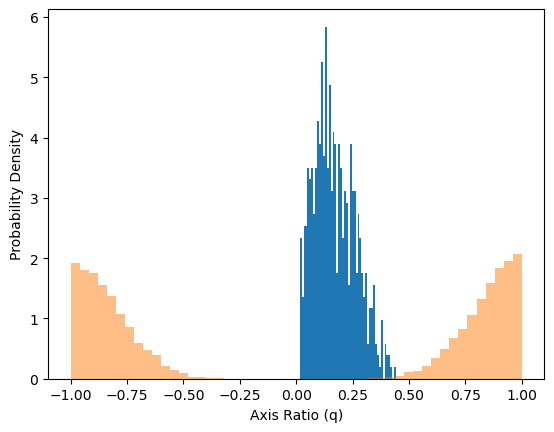

In [19]:
plt.hist(q, bins=50, density=True)
plt.hist(e1, bins=50, density=True, alpha=0.5, label='e1')
plt.xlabel('Axis Ratio (q)')
plt.ylabel('Probability Density')
plt.show()

In [25]:
import numpy as np
from scipy.optimize import minimize
from math import sqrt

def r_from_z(z):
    return (1.0 - z) / (1.0 + z)

def log_pz(z, sigma):
    # returns log p_Z(z; sigma)
    r = r_from_z(z)
    # guard against tiny denom
    if np.any(r < 0):
        return -np.inf
    return np.log(r) - 2*np.log(sigma) - (r**2)/(2*sigma**2) + 2*np.log(1+r) - np.log(2.0)

# Method of moments
def sigma_mom(z_samples):
    r = r_from_z(z_samples)
    return np.sqrt(0.5 * np.mean(r**2))

# MLE (numeric)
def sigma_mle(z_samples, sigma_init=None):
    if sigma_init is None:
        sigma_init = sigma_mom(z_samples)
    def neg_loglike(log_sigma):
        sigma = np.exp(log_sigma)   # optimize in log-space for positivity
        ll = np.sum(log_pz(z_samples, sigma))
        return -ll
    res = minimize(neg_loglike, np.log(sigma_init), method='Nelder-Mead')
    return float(np.exp(res.x[0]))

# Example usage:
z_samples = random.normal(0.5, 0.1, 1000)
sigma_hat_mom = sigma_mom(z_samples)
sigma_hat_mle = sigma_mle(z_samples)
sigma_hat_mle, sigma_hat_mom

(0.24707089741455868, 0.24707089741455868)

In [28]:
c.to(u.Angstrom / u.s).value

NameError: name 'c' is not defined

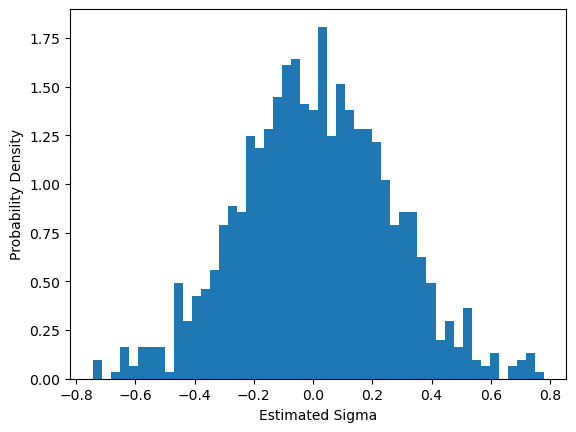

In [27]:
plt.hist(random.normal(0, sigma_hat_mom, 1000), bins=50, density=True)
#plt.hist(sigma_hat_mom, bins=50, density=True, alpha=0.5, label='Method of Moments')

plt.xlabel('Estimated Sigma')
plt.ylabel('Probability Density')
plt.show()